In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import sklearn.preprocessing as LabelEncoder
import sklearn.preprocessing as OneHotEncoder

In [2]:
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


In [3]:
#A) seu código aqui
df.dtypes

Age                   float64
Gender                    str
Income                    str
Education                 str
Marital Status            str
Number of Children      int64
Home Ownership            str
Credit Score              str
dtype: object

In [4]:
#seu código aqui
df['Income'] = df['Income'].str.strip()
df['Income'] = df['Income'].str.replace(r'[^0-9,\.]', '', regex=True)
df['Income'] = df['Income'].str.replace('.', '', regex=False)
df['Income'] = df['Income'].str.replace(',', '.', regex=False)
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

In [5]:
mapeamento = {'Male': 0,
              'Female': 1}
df['Gender'] = df['Gender'].map(mapeamento)
print(df['Gender'].value_counts())

Gender
1    86
0    78
Name: count, dtype: int64


In [6]:
mapeamento = {"High School Diploma": 0,
              "Associate's Degree": 1,
              "Bachelor's Degree": 2,
              "Master's Degree": 3,
              "Doctorate": 4}
df['Education'] = df['Education'].map(mapeamento)
print(df['Education'].value_counts())

Education
2    42
3    36
4    31
0    30
1    25
Name: count, dtype: int64


In [7]:
mapeamento = {'Single': 0,
              'Married': 1}
df['Marital Status'] = df['Marital Status'].map(mapeamento)
print(df['Marital Status'].value_counts())

Marital Status
1    87
0    77
Name: count, dtype: int64


In [8]:
mapeamento = {'Low': 0,
              'Average': 1,
              'High': 2}
df['Credit Score'] = df['Credit Score'].map(mapeamento)
print(df['Credit Score'].value_counts())

Credit Score
2    113
1     36
0     15
Name: count, dtype: int64


In [9]:
mapeamento = {'Owned': 0,
              'Rented': 1}
df['Home Ownership'] = df['Home Ownership'].map(mapeamento)
print(df['Home Ownership'].value_counts())

Home Ownership
0    111
1     53
Name: count, dtype: int64


In [10]:
#seu código aqui
df['Age'].isnull().sum()

np.int64(34)

In [11]:
(df.isnull().sum() / len(df)) * 100

Age                   20.731707
Gender                 0.000000
Income                 0.000000
Education              0.000000
Marital Status         0.000000
Number of Children     0.000000
Home Ownership         0.000000
Credit Score           0.000000
dtype: float64

In [12]:
df.dropna(subset=['Age'], inplace=True)

In [13]:
df['Age'].isnull().sum()

np.int64(0)

Decidi excluir os dados da coluna Age por serem uma porcentagem relativamente pequena dos dados.

In [14]:
#seu código aqui
df.describe()

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000
mean,37.507692,0.523077,84288.461538,2.107692,0.523077,0.661538,0.338462,1.592308
std,8.500110,0.501399,33063.942361,1.342485,0.501399,0.902656,0.475017,0.643346
min,25.000000,0.000000,25000.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,58125.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,36.000000,1.000000,82500.000000,2.000000,1.000000,0.000000,0.000000,2.000000
75%,45.000000,1.000000,105000.000000,3.000000,1.000000,1.000000,1.000000,2.000000
max,53.000000,1.000000,162500.000000,4.000000,1.000000,3.000000,1.000000,2.000000


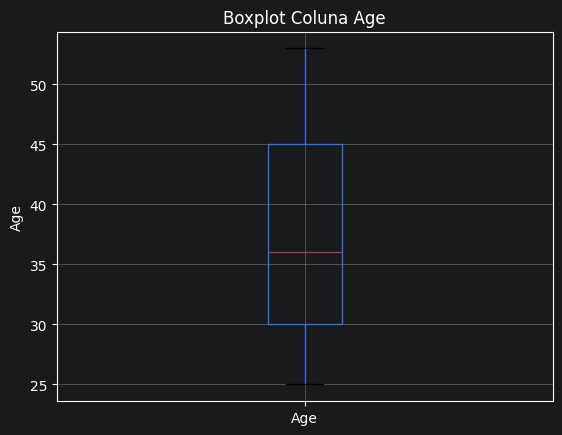

In [15]:
df.boxplot(column='Age')
plt.title('Boxplot Coluna Age')
plt.ylabel('Age')
plt.show()

Vemos que não temos outliers nessa coluna e que a média fica próxima dos 35 anos.

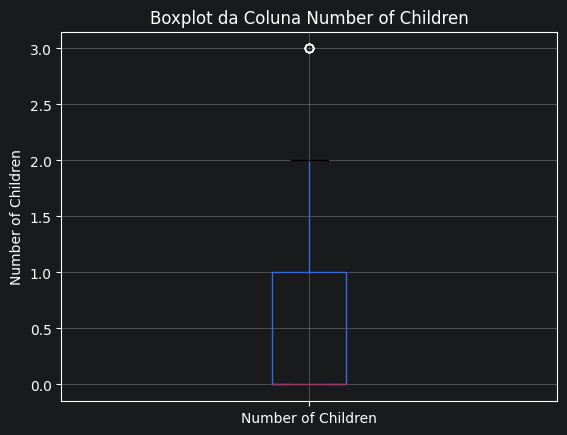

In [16]:
df.boxplot(column= 'Number of Children')
plt.title('Boxplot da Coluna Number of Children')
plt.ylabel('Number of Children')
plt.show()

Podemos ver que temos outliers nesse gráfico de número de filhos.

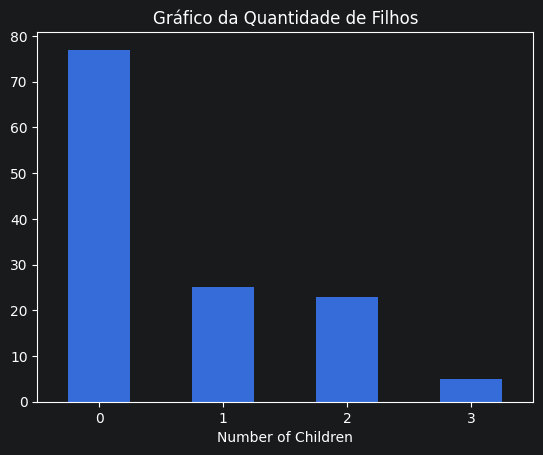

In [17]:
contagem_filhos = df['Number of Children'].value_counts()
porcentagen_filhos = (contagem_filhos / contagem_filhos.sum()) * 100
ax = contagem_filhos.plot(kind='bar')
plt.xticks(rotation= 0)
plt.title('Gráfico da Quantidade de Filhos')
plt.show()

Vemos nesse gráfico que temos uma grande porcentagem de pessoas que não possuem filhos, o que pode ser que faça com que as pessoas que possuem 3 filhos sejam vistas como outliers.

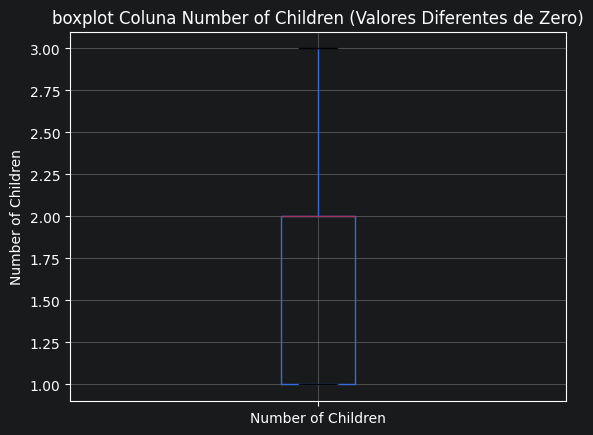

In [18]:
df_nao_zero = df[df['Number of Children'] != 0]
df_nao_zero.boxplot(column='Number of Children')
plt.title('boxplot Coluna Number of Children (Valores Diferentes de Zero)')
plt.xticks(rotation= 0)
plt.ylabel('Number of Children')
plt.show()

Aqui vemos que se retirados os dados das pessoas que não possuem filhos temos um gráfico sem outliers.

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

Foi visto no gráfico anterior que as pessoas que tinham 3 filhos se tornavam outliers pela grande parte das pessoas que não possuem nenhum filho.

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



In [19]:
#seu código aqui
fig = px.histogram(df, x='Age', color='Marital Status', barmode='stack')

fig.update_layout(title= 'Relação entre Idade e Status Civil',
                  xaxis_title= 'Idade',
                  yaxis_title= 'Status Civil',
                  legend_title='Status Civil')
fig.show()

Vemos nesse gráfico que pessoas que tem por volta de 35 a 39 anos e 45 a 54 anos são mais propensas a estarem casadas.

In [20]:
fig = px.histogram(df, x='Credit Score', color='Education', barmode='stack')

fig.update_layout(title='Relação entre Score de Crédito e Nível de Escolaridade',
                  xaxis_title='Score de Crédito',
                  yaxis_title='Nível de Escolaridade',
                  legend_title='Nível de Escolaridade')
fig.show()

Vemos nesse gráfico que as maiores liberações de crédito vêm para o mestrado seguido por bacharel e doutorado.

In [21]:
fig = px.histogram(df, x='Age', color='Income', barmode='stack')

fig.update_layout(title='Relação entre Idade e Salário',
                  xaxis_title= 'Idade',
                  yaxis_title='Salário',
                  legend_title='Salário')
fig.show()

Vemos nesse gráfico que temos maior concentração de salários mais altos na faixa etária de 50 a 54 anos sendo o menor 115 mil e a maior 162.500.

In [22]:
fig = px.histogram(df, x='Credit Score', color='Income', barmode='stack')
fig.update_layout(title= ' Relação entre Salário e Score de Crédito',
                  xaxis_title= 'Salário',
                  yaxis_title= 'Score de Crédito',
                  legend_title= 'Score de Crédito')
fig.show()

Vemos nesse gráfico que o score de crédito é mais baixo para quem ganha entre 25 mil e 32.500. Valores que não são visto no nível médio e alto.

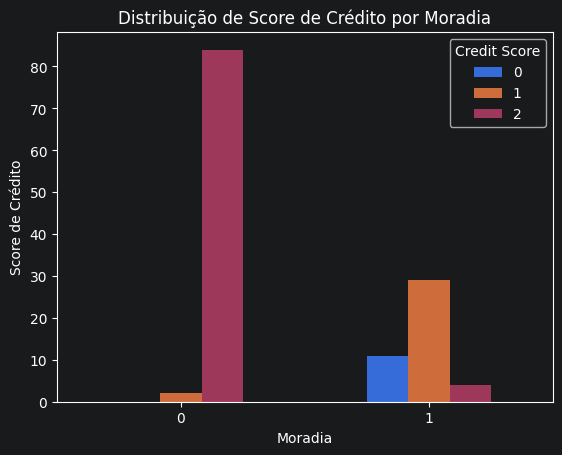

In [23]:
ct = pd.crosstab(df['Home Ownership'], df['Credit Score'])
ct.plot(kind='bar')
plt.xticks(rotation=0)
plt.title('Distribuição de Score de Crédito por Moradia')
plt.xlabel('Moradia')
plt.ylabel('Score de Crédito')
plt.show()

Neste gráfico é visto que os maiores scores de crédito são dados para quem tem residência própria.

In [25]:
#seu código aqui
df.select_dtypes(include= ['number']).corr()

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
Age,1.000000,-0.230129,0.685213,0.203724,0.508333,0.078137,-0.705250,0.656199
Gender,-0.230129,1.000000,-0.492901,0.099927,0.259962,0.411333,0.032047,-0.198907
Income,0.685213,-0.492901,1.000000,0.243705,0.472687,0.114724,-0.698987,0.742262
Education,0.203724,0.099927,0.243705,1.000000,0.399354,0.330973,-0.483062,0.535904
Marital Status,0.508333,0.259962,0.472687,0.399354,1.000000,0.702507,-0.716545,0.618166
Number of Children,0.078137,0.411333,0.114724,0.330973,0.702507,1.000000,-0.508164,0.427984
Home Ownership,-0.705250,0.032047,-0.698987,-0.483062,-0.716545,-0.508164,1.000000,-0.838648
Credit Score,0.656199,-0.198907,0.742262,0.535904,0.618166,0.427984,-0.838648,1.000000


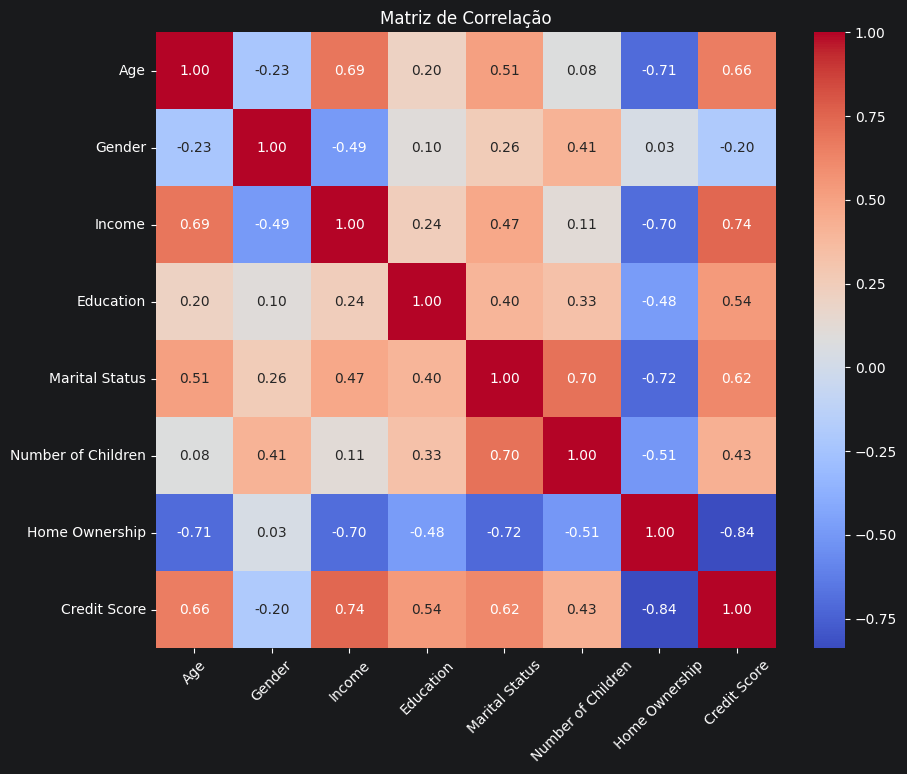

In [26]:
correlation_matrix = df.select_dtypes(include= ['number']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.xticks(rotation= 45)
plt.show()

Dentro das correlações positivas estão:

Temos uma correlação de 0,74 (alta) de salário e score de crédito;

Temos uma correlação de 0,70 (alta) de status de relacionamento com o número de filhos;

Temos uma correlação de 0,69 (média) de idade e salário;

Temos uma correlação de 0,66 (média) de idade e score de crédito;

Temos uma correlação de 0,62 (média) de status de relacionamento com score de crédito;

Temos uma correlação de 0,51 (média) de idade e status de relacionamento;

Temos uma correlação de 0,47 (média) de salário e status de relacionamento;

Temos uma correlação de 0,43 (média) de número de filhos e score de crédito;

Temos uma correlação de 0,41 (média) de idade e número de filhos.

Dentro das correlações negativas estão:

Temos uma correlação de -0,84 (alta) de score de crédito e propietário de casas;

Temos uma correlação de -0,72 (alta) de proprietário de casas e status de relacionamento;

Temos uma correlação de -0,71 (alta) de proprietários de casas e idade;

Temos uma correlação de -0,70 (alta) de proprietários de casas e salário;

Temos uma correlação de -0,51 (média) de proprietários de casas e número de filhos;

Temos uma correlação de -0,49 (média) de salário e gênero;

Temos uma correlação de -0,44 (média) de educação e número de filhos;

Temos uma correlação de -0,38 (média) de educação e score de crédito.

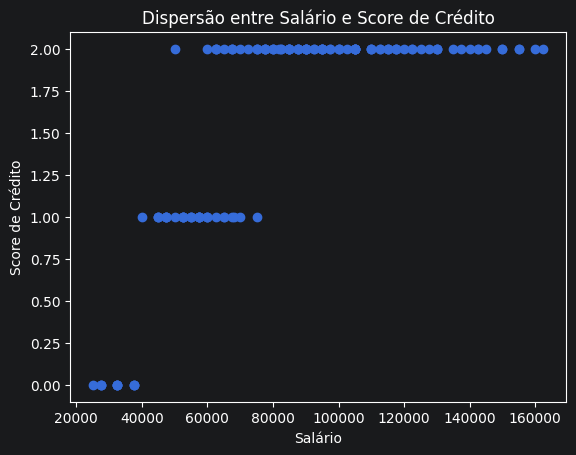

In [27]:
# sua justificativa aqui
plt.scatter(df['Income'], df['Credit Score'])
plt.xlabel('Salário')
plt.ylabel('Score de Crédito')
plt.title('Dispersão entre Salário e Score de Crédito')
plt.show()

Vemos que o score de crédito é mais alto na medida que o salário vai aumentando e sendo mais facilitado a partir do salário de 60 mil.

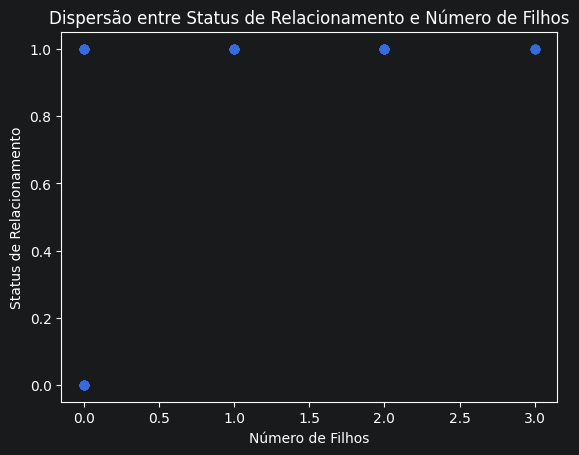

In [28]:
plt.scatter(df['Number of Children'], df['Marital Status'])
plt.xlabel('Número de Filhos')
plt.ylabel('Status de Relacionamento')
plt.title('Dispersão entre Status de Relacionamento e Número de Filhos')
plt.show()

Aqui vemos que não temos pais ou mães solteiras, sendo todos famílias completas e estáveis.

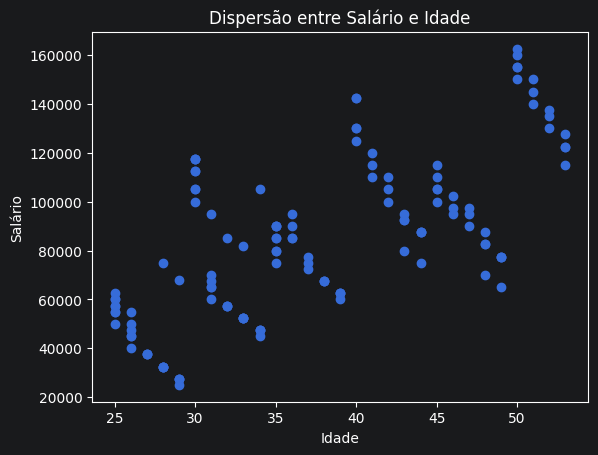

In [29]:
plt.scatter(df['Age'], df['Income'])
plt.xlabel('Idade')
plt.ylabel('Salário')
plt.title('Dispersão entre Salário e Idade')
plt.show()

Vemos nesse gráfico que pessoas com 50 anos ou mais tendem a ter uma diminuição no salário.

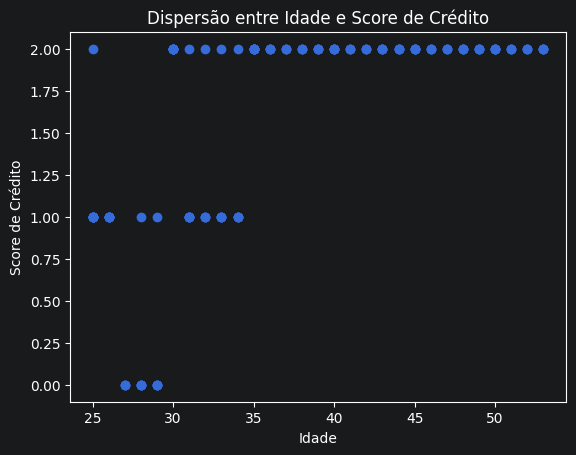

In [30]:
plt.scatter(df['Age'], df['Credit Score'])
plt.xlabel('Idade')
plt.ylabel('Score de Crédito')
plt.title('Dispersão entre Idade e Score de Crédito')
plt.show()

Vemos aqui que as pessoas que tem maiores scores de crédito têm mais de 30 anos.

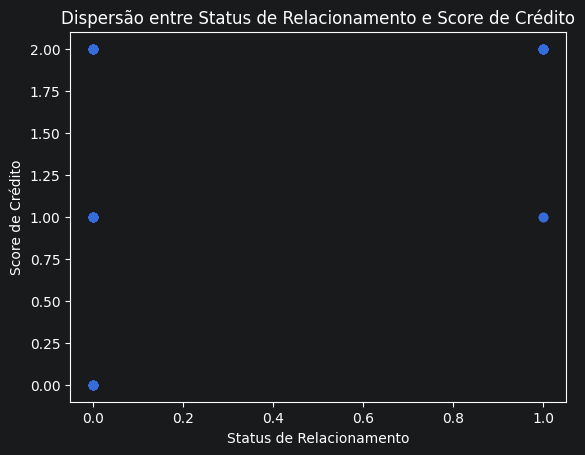

In [31]:
plt.scatter(df['Marital Status'], df['Credit Score'])
plt.xlabel('Status de Relacionamento')
plt.ylabel('Score de Crédito')
plt.title('Dispersão entre Status de Relacionamento e Score de Crédito')
plt.show()

Nesse gráfico vemos que não são dados score de crédito baixo para pessoas casadas.

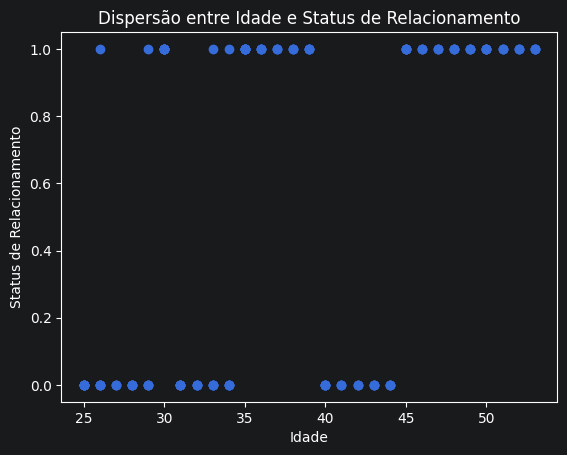

In [32]:
plt.scatter(df['Age'], df['Marital Status'])
plt.xlabel('Idade')
plt.ylabel('Status de Relacionamento')
plt.title('Dispersão entre Idade e Status de Relacionamento')
plt.show()

Vemos aqui que temos pessoas solteiras na faixa de 40 a 44 anos e se casam a partir dos 45 anos e menor índice de pessoas casadas entre 25 e 30 anos.

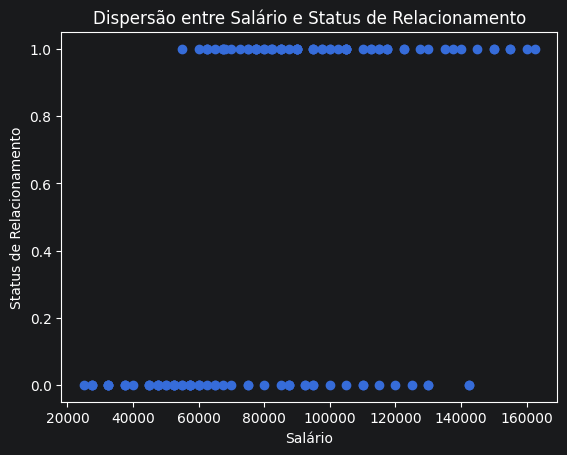

In [33]:
plt.scatter(df['Income'], df['Marital Status'])
plt.xlabel('Salário')
plt.ylabel('Status de Relacionamento')
plt.title('Dispersão entre Salário e Status de Relacionamento')
plt.show()

Vemos que no caso de pessoas solteiras o salário não vai muito além dos 140 mil, já nas pessoas casadas, não temos muitos valores abaixo de 60 mil e podem ultrapassar os 160 mil.

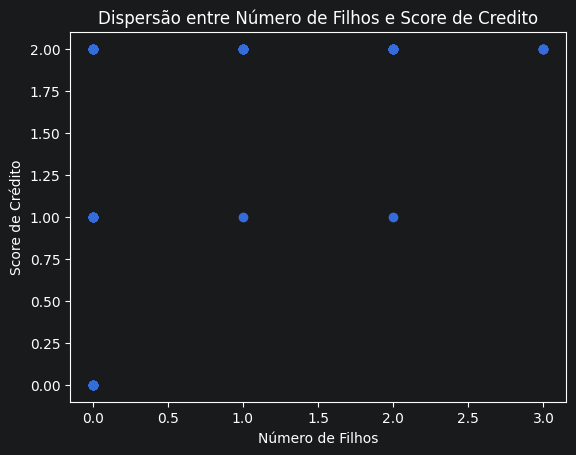

In [34]:
plt.scatter(df['Number of Children'], df['Credit Score'])
plt.xlabel('Número de Filhos')
plt.ylabel('Score de Crédito')
plt.title('Dispersão entre Número de Filhos e Score de Credito')
plt.show()

Vemos nesse gráfico que somente pessoas que não possuem filhos têm o score de crédito baixo e pessoas que possuem 3 filhos possuem score de crédito alto.

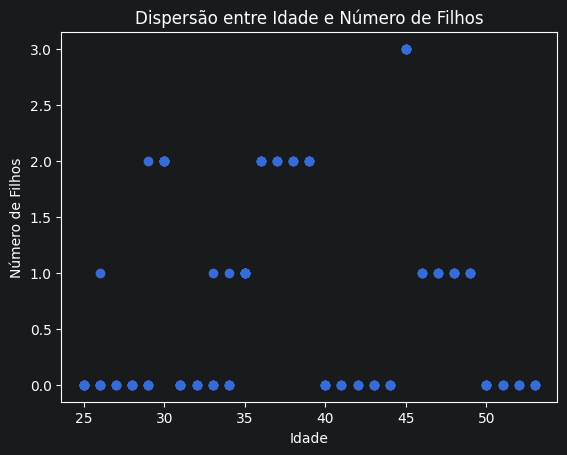

In [35]:
plt.scatter(df['Age'], df['Number of Children'])
plt.xlabel('Idade')
plt.ylabel('Número de Filhos')
plt.title('Dispersão entre Idade e Número de Filhos')
plt.show()

Aqui vemos que temos muitas pessoas que não possuem filhos, e poucas pessoas que possuem 1 ou mais filhos.

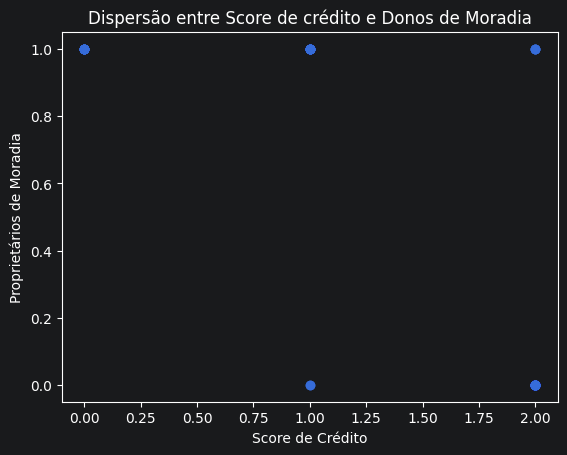

In [36]:
plt.scatter(df['Credit Score'], df['Home Ownership'])
plt.xlabel('Score de Crédito')
plt.ylabel('Proprietários de Moradia')
plt.title('Dispersão entre Score de crédito e Donos de Moradia')
plt.show()

Os scores de crédito baixo não são dados as pessoas que vivem de aluguel.

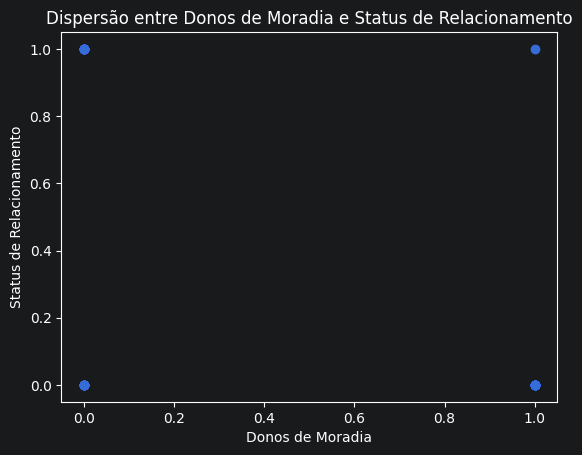

In [37]:
plt.scatter(df['Home Ownership'], df['Marital Status'])
plt.xlabel('Donos de Moradia')
plt.ylabel('Status de Relacionamento')
plt.title('Dispersão entre Donos de Moradia e Status de Relacionamento')
plt.show()

Aqui podemos ver que temos tanto casados quanto solteiros morando em casas próprias ou morando de aluguel.

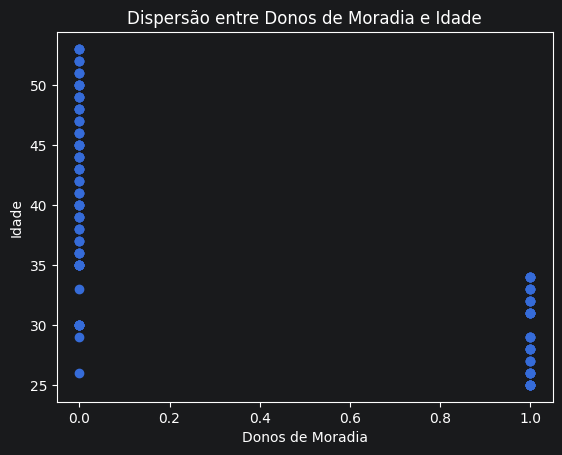

In [38]:
plt.scatter(df['Home Ownership'], df['Age'])
plt.xlabel('Donos de Moradia')
plt.ylabel('Idade')
plt.title('Dispersão entre Donos de Moradia e Idade')
plt.show()

Podemos ver aqui que pessoas de 35 anos ou mais já possuem imóvel próprio e menores dessa idade moram alugados.

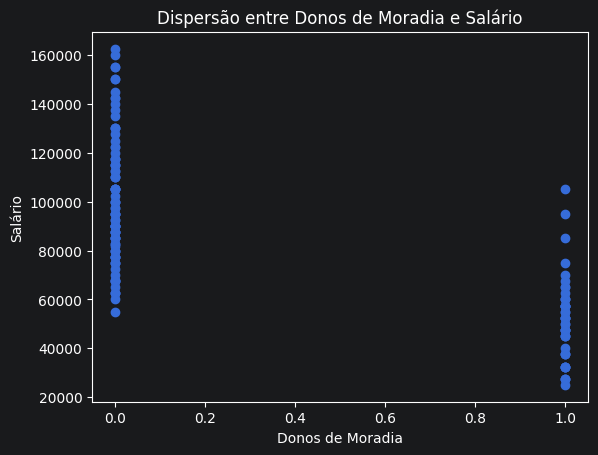

In [39]:
plt.scatter(df['Home Ownership'], df['Income'])
plt.xlabel('Donos de Moradia')
plt.ylabel('Salário')
plt.title('Dispersão entre Donos de Moradia e Salário')
plt.show()

Pessoas que vão ganhando mais tendem a ter imóvel próprio conforme o tempo.

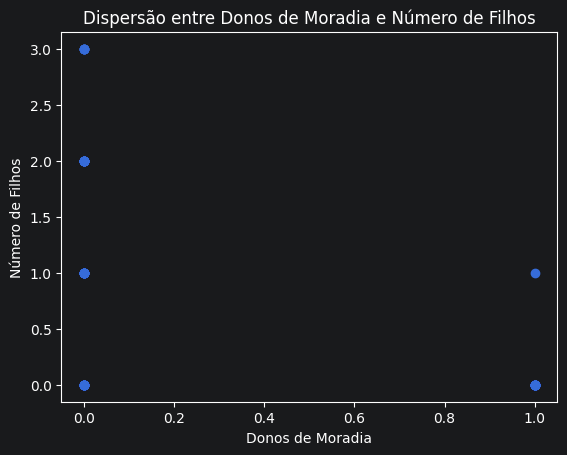

In [40]:
plt.scatter(df['Home Ownership'], df['Number of Children'])
plt.xlabel('Donos de Moradia')
plt.ylabel('Número de Filhos')
plt.title('Dispersão entre Donos de Moradia e Número de Filhos')
plt.show()

Aqui vemos que pessoas que possuem 2 ou 3 filhos não possuem casa própria.

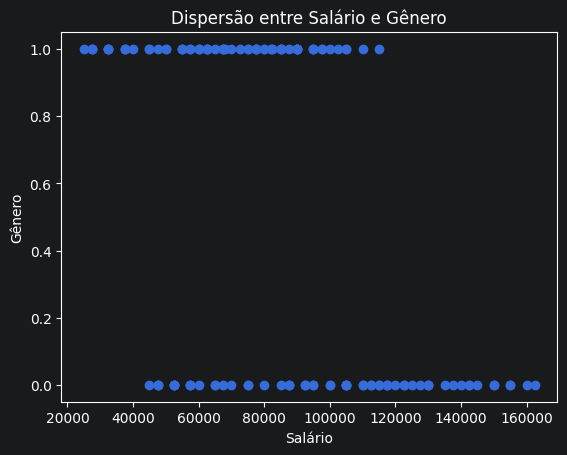

In [41]:
plt.scatter(df['Income'], df['Gender'])
plt.xlabel('Salário')
plt.ylabel('Gênero')
plt.title('Dispersão entre Salário e Gênero')
plt.show()

Vemos aqui que homens não ganham menos que 40 mil e mulheres não ganham mais de 120 mil.

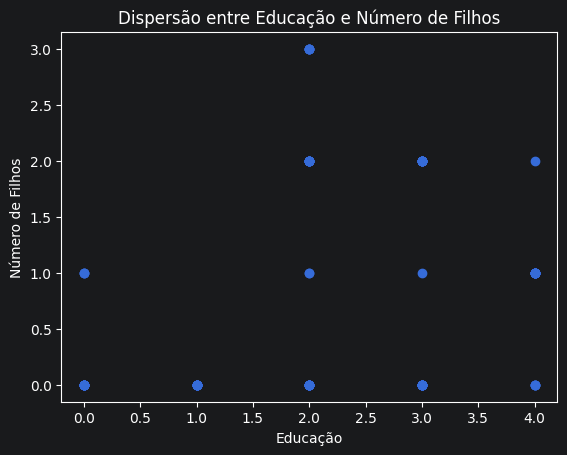

In [42]:
plt.scatter(df['Education'], df['Number of Children'])
plt.xlabel('Educação')
plt.ylabel('Número de Filhos')
plt.title('Dispersão entre Educação e Número de Filhos')
plt.show()

Vimos que temos pessoas com melhores formações não tendo ou tendo apenas um filho.

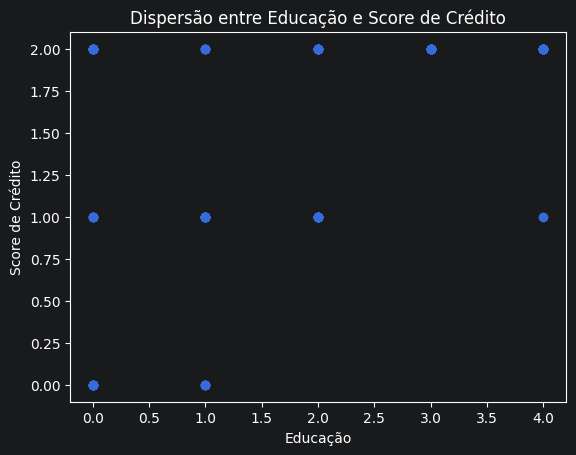

In [43]:
plt.scatter(df['Education'], df['Credit Score'])
plt.xlabel('Educação')
plt.ylabel('Score de Crédito')
plt.title('Dispersão entre Educação e Score de Crédito')
plt.show()

Aqui vemos que pessoas que possuem níveis mais altos de escolaridade possuem scores de crédito médios e altos.

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

In [44]:
#seu código aqui
for col in df.columns:
    print(col, df[col].nunique())

Age 29
Gender 2
Income 50
Education 5
Marital Status 2
Number of Children 4
Home Ownership 2
Credit Score 3


In [45]:
df = pd.DataFrame({'Gender': ['Male', 'Female']})
df_onehot = pd.get_dummies(df, columns=['Gender'], dtype=int)
print(df_onehot)

   Gender_Female  Gender_Male
0              0            1
1              1            0


In [46]:
df = pd.DataFrame({'Education': ["High School Diploma", "Associate's Degree", "Bachelor's Degree", "Master's Degree", "Doctorate"]})
df_onehot = pd.get_dummies(df, columns=['Education'], dtype=int)
print(df_onehot)

   Education_Associate's Degree  Education_Bachelor's Degree  \
0                             0                            0   
1                             1                            0   
2                             0                            1   
3                             0                            0   
4                             0                            0   

   Education_Doctorate  Education_High School Diploma  \
0                    0                              1   
1                    0                              0   
2                    0                              0   
3                    0                              0   
4                    1                              0   

   Education_Master's Degree  
0                          0  
1                          0  
2                          0  
3                          1  
4                          0  


In [47]:
df = pd.DataFrame({'Marital Status': ['Single', 'Married']})
df_onehot = pd.get_dummies(df, columns=['Marital Status'], dtype=int)
print(df_onehot)

   Marital Status_Married  Marital Status_Single
0                       0                      1
1                       1                      0


In [48]:
df = pd.DataFrame({'Number of Children': ["0", "1", "2", "3"]})
df_onehot = pd.get_dummies(df, columns=['Number of Children'], dtype=int)
print(df_onehot)

   Number of Children_0  Number of Children_1  Number of Children_2  \
0                     1                     0                     0   
1                     0                     1                     0   
2                     0                     0                     1   
3                     0                     0                     0   

   Number of Children_3  
0                     0  
1                     0  
2                     0  
3                     1  


In [49]:
df = pd.DataFrame({'Home Ownership': ['Rented', 'Owned']})
df_onehot = pd.get_dummies(df, columns=['Home Ownership'], dtype=int)
print(df_onehot)

   Home Ownership_Owned  Home Ownership_Rented
0                     0                      1
1                     1                      0


In [50]:
df = pd.DataFrame({'Credit Score': ['Low', 'Average', 'High']})
df_onehot = pd.get_dummies(df, columns=['Credit Score'], dtype=int)
print(df_onehot)

   Credit Score_Average  Credit Score_High  Credit Score_Low
0                     0                  0                 1
1                     1                  0                 0
2                     0                  1                 0


In [51]:
df = pd.read_csv('CREDIT_SCORE_PROJETO_PARTE1.csv', delimiter=';')
df_temp = df[['Age', 'Income']]

In [52]:
df.dropna(subset=['Age'], inplace=True)

In [53]:
df.describe()

,Age,Number of Children
count,130.000000,130.000000
mean,37.507692,0.661538
std,8.500110,0.902656
min,25.000000,0.000000
25%,30.000000,0.000000
50%,36.000000,0.000000
75%,45.000000,1.000000
max,53.000000,3.000000


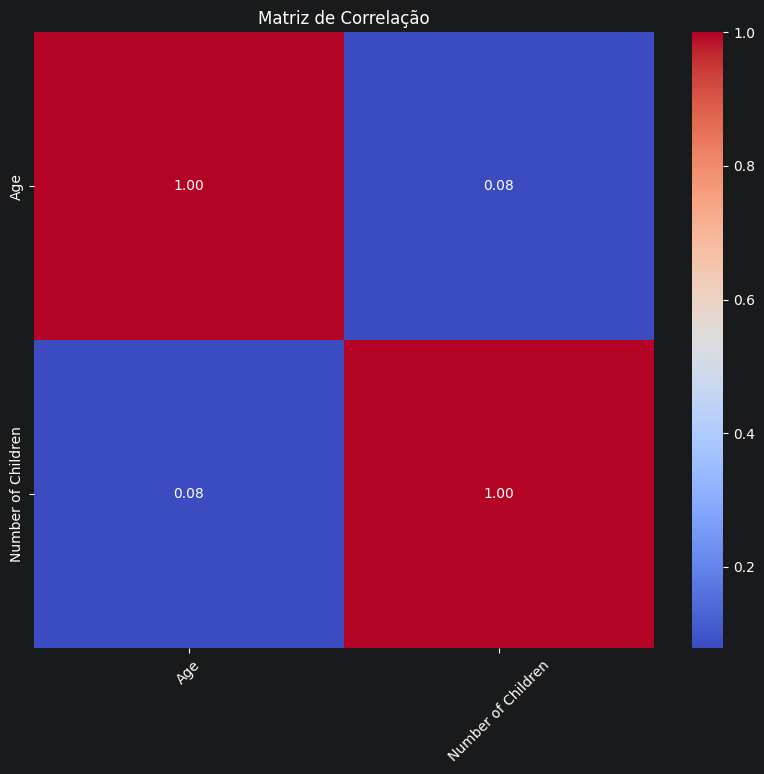

In [54]:
#seu código aqui
correlation_matrix = df.select_dtypes(include= ['number']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.xticks(rotation= 45)
plt.show()

Visto no gráfico que não temos correlação média nem  alta de idade com o número de filhos.

In [55]:
print(df.head())

    Age  Gender      Income            Education Marital Status  \
0  25.0  Female   50.000,00    Bachelor's Degree         Single   
1  30.0    Male  100.000,00      Master's Degree        Married   
2  35.0  Female   75.000,00            Doctorate        Married   
3  40.0    Male  125.000,00  High School Diploma         Single   
4  45.0  Female  100.000,00    Bachelor's Degree        Married   

   Number of Children Home Ownership Credit Score  
0                   0         Rented         High  
1                   2          Owned         High  
2                   1          Owned         High  
3                   0          Owned         High  
4                   3          Owned         High  


**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [56]:
#seu código aqui
X = df.drop('Credit Score', axis=1)
y = df['Credit Score']

In [57]:
from sklearn.model_selection import train_test_split

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [59]:
X_train

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership
37,36.0,Female,"85.000,00",Master's Degree,Married,2,Owned
80,33.0,Male,"52.500,00",High School Diploma,Single,0,Rented
138,40.0,Male,"130.000,00",High School Diploma,Single,0,Owned
114,43.0,Male,"95.000,00",Master's Degree,Single,0,Owned
28,49.0,Female,"65.000,00",Doctorate,Married,1,Owned
...,...,...,...,...,...,...,...
96,40.0,Male,"142.500,00",High School Diploma,Single,0,Owned
131,26.0,Female,"55.000,00",Bachelor's Degree,Married,1,Owned
27,44.0,Male,"75.000,00",Master's Degree,Single,0,Owned
117,29.0,Female,"27.500,00",High School Diploma,Single,0,Rented


In [60]:
X_test

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership
68,31.0,Male,"67.500,00",Bachelor's Degree,Single,0,Rented
53,29.0,Female,"27.500,00",High School Diploma,Single,0,Rented
32,40.0,Male,"130.000,00",High School Diploma,Single,0,Owned
44,42.0,Male,"100.000,00",Master's Degree,Single,0,Owned
140,50.0,Male,"155.000,00",Master's Degree,Married,0,Owned
69,36.0,Female,"90.000,00",Master's Degree,Married,2,Owned
94,30.0,Male,"117.500,00",Master's Degree,Married,2,Owned
130,31.0,Male,"95.000,00",Doctorate,Single,0,Rented
106,32.0,Male,"57.500,00",Associate's Degree,Single,0,Rented
39,46.0,Female,"95.000,00",High School Diploma,Married,1,Owned


In [61]:
y_train

37        High
80     Average
138       High
114       High
28        High
        ...   
96        High
131    Average
27        High
117        Low
127       High
Name: Credit Score, Length: 97, dtype: str

In [62]:
y_test

68     Average
53         Low
32        High
44        High
140       High
69        High
94        High
130       High
106    Average
39        High
120       High
40        High
77        High
4         High
122    Average
125    Average
49        High
105        Low
118    Average
109       High
31        High
23        High
154    Average
24         Low
160    Average
58     Average
95        High
103       High
60        High
0         High
25     Average
55        High
64        High
Name: Credit Score, dtype: str

In [63]:
print('Tamanho de X_train:', X_train.shape)

Tamanho de X_train: (97, 7)


In [64]:
print('Tamanho de X_test:', X_test.shape)

Tamanho de X_test: (33, 7)


In [65]:
print('tamanho de y_train:', y_train.shape)

tamanho de y_train: (97,)


In [66]:
print('Tamanho de y_test:', y_test.shape)

Tamanho de y_test: (33,)


**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

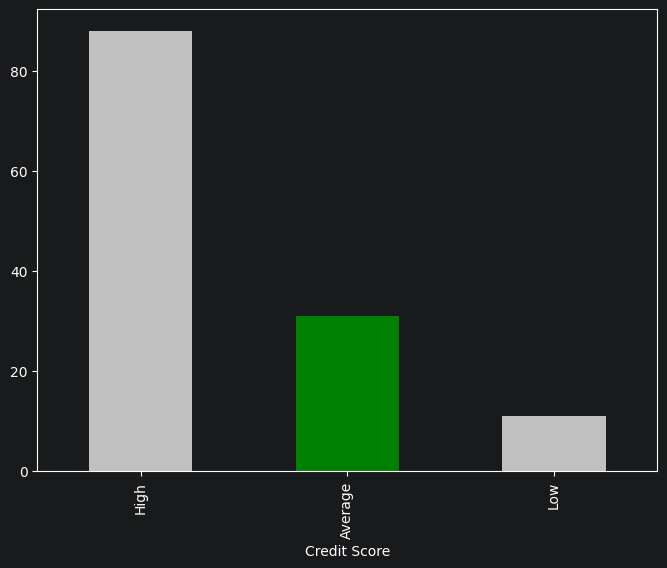

In [67]:
#seu código aqui
Credit_Score_counts = df['Credit Score'].value_counts()
plt.figure(figsize=(8, 6))
Credit_Score_counts.plot(kind='bar', color=['silver', 'green'])
plt.show()

In [68]:
print((df['Credit Score'].value_counts(normalize=True) * 100))

Credit Score
High       67.692308
Average    23.846154
Low         8.461538
Name: proportion, dtype: float64


Temos apenas 8% das pessoas com baixo score de crédito, é visto no decorrer da análise que são as pessoas que são mais jovens que moram de aluguel ou pela quantidade de filhos ser maior e a graduação escolar ser menor.

**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

In [69]:
print(X_train.isna().sum())
print(y_train.isna().any())

Age                   0
Gender                0
Income                0
Education             0
Marital Status        0
Number of Children    0
Home Ownership        0
dtype: int64
False


In [70]:
(df.isnull().sum() / len(df) * 100)

Age                   0.0
Gender                0.0
Income                0.0
Education             0.0
Marital Status        0.0
Number of Children    0.0
Home Ownership        0.0
Credit Score          0.0
dtype: float64

In [71]:
print(df['Age'].head(10))

0     25.0
1     30.0
2     35.0
3     40.0
4     45.0
5     50.0
6     26.0
7     31.0
21    43.0
22    48.0
Name: Age, dtype: float64


In [72]:
X_train = pd.get_dummies(X_train, drop_first=True)

In [73]:
#seu código aqui
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print('Distribuição das classes após o balanceamento:')
print(y_train_balanced.value_counts())
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print('Distribuição das classes após balanceamento')
print(y_train_balanced.value_counts())

Distribuição das classes após o balanceamento:
Credit Score
High       67
Average    67
Low        67
Name: count, dtype: int64
Distribuição das classes após balanceamento
Credit Score
High       67
Average    67
Low        67
Name: count, dtype: int64


In [74]:
train_balance =  y_train_balanced.value_counts()
print('Balanceamento em y_train:')
print(train_balance)

Balanceamento em y_train:
Credit Score
High       67
Average    67
Low        67
Name: count, dtype: int64


In [75]:
y_train_balanced.to_csv('y_train_balanced.csv', index=False)

In [76]:
X_train_balanced.to_csv('X_train_balanced.csv', index=False)

In [77]:
y_test.to_csv('y_test.csv', index=False)

In [78]:
X_test.to_csv('X_test.csv', index=False)